In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.pylab as pylab
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,accuracy_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.svm import SVC,SVR
from xgboost import XGBClassifier,XGBRegressor
from sklearn.ensemble import GradientBoostingClassifier,GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.ion() 
%matplotlib inline



In [6]:
df= pd.read_csv('diamonds.csv')
print(df.head())

   Unnamed: 0  carat      cut color clarity  ...  table  price     x     y     z
0           1   0.23    Ideal     E     SI2  ...   55.0    326  3.95  3.98  2.43
1           2   0.21  Premium     E     SI1  ...   61.0    326  3.89  3.84  2.31
2           3   0.23     Good     E     VS1  ...   65.0    327  4.05  4.07  2.31
3           4   0.29  Premium     I     VS2  ...   58.0    334  4.20  4.23  2.63
4           5   0.31     Good     J     SI2  ...   58.0    335  4.34  4.35  2.75

[5 rows x 11 columns]


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB
None


In [8]:
print(df.describe())



         Unnamed: 0         carat  ...             y             z
count  53940.000000  53940.000000  ...  53940.000000  53940.000000
mean   26970.500000      0.797940  ...      5.734526      3.538734
std    15571.281097      0.474011  ...      1.142135      0.705699
min        1.000000      0.200000  ...      0.000000      0.000000
25%    13485.750000      0.400000  ...      4.720000      2.910000
50%    26970.500000      0.700000  ...      5.710000      3.530000
75%    40455.250000      1.040000  ...      6.540000      4.040000
max    53940.000000      5.010000  ...     58.900000     31.800000

[8 rows x 8 columns]


In [9]:
# Check for missing values
print(df.isnull().sum())



Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


In [10]:
df.shape
## DATA PREPROCESSING 
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [11]:
#The first column seems to be just index
df = df.drop(["Unnamed: 0"], axis=1)
print([df.describe()])

[              carat         depth  ...             y             z
count  53940.000000  53940.000000  ...  53940.000000  53940.000000
mean       0.797940     61.749405  ...      5.734526      3.538734
std        0.474011      1.432621  ...      1.142135      0.705699
min        0.200000     43.000000  ...      0.000000      0.000000
25%        0.400000     61.000000  ...      4.720000      2.910000
50%        0.700000     61.800000  ...      5.710000      3.530000
75%        1.040000     62.500000  ...      6.540000      4.040000
max        5.010000     79.000000  ...     58.900000     31.800000

[8 rows x 7 columns]]


In [12]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [13]:
# Min value of "x", "y", "z" are zero this indicates that there are faulty values in data that represents dimensionless or 2-dimensional diamonds. So we need to filter out those as it clearly faulty data points.
df=df.drop(df[(df.x==0) | (df.y==0) | (df.z==0)].index)
print(df.shape)

(53920, 10)


In [14]:
# We can clearly spot outliers in these attributes. Next up, we will remove these data points.
df=df[(df["depth"]<75) & (df["depth"]>45)]
df=df[(df["table"]<80) & (df["table"]>40)]
df=df[(df["x"]<30)]
df=df[(df["y"]<30)]
df=df[(df["z"]<30)&(df["z"]>2)]
print(df.shape)


(53907, 10)


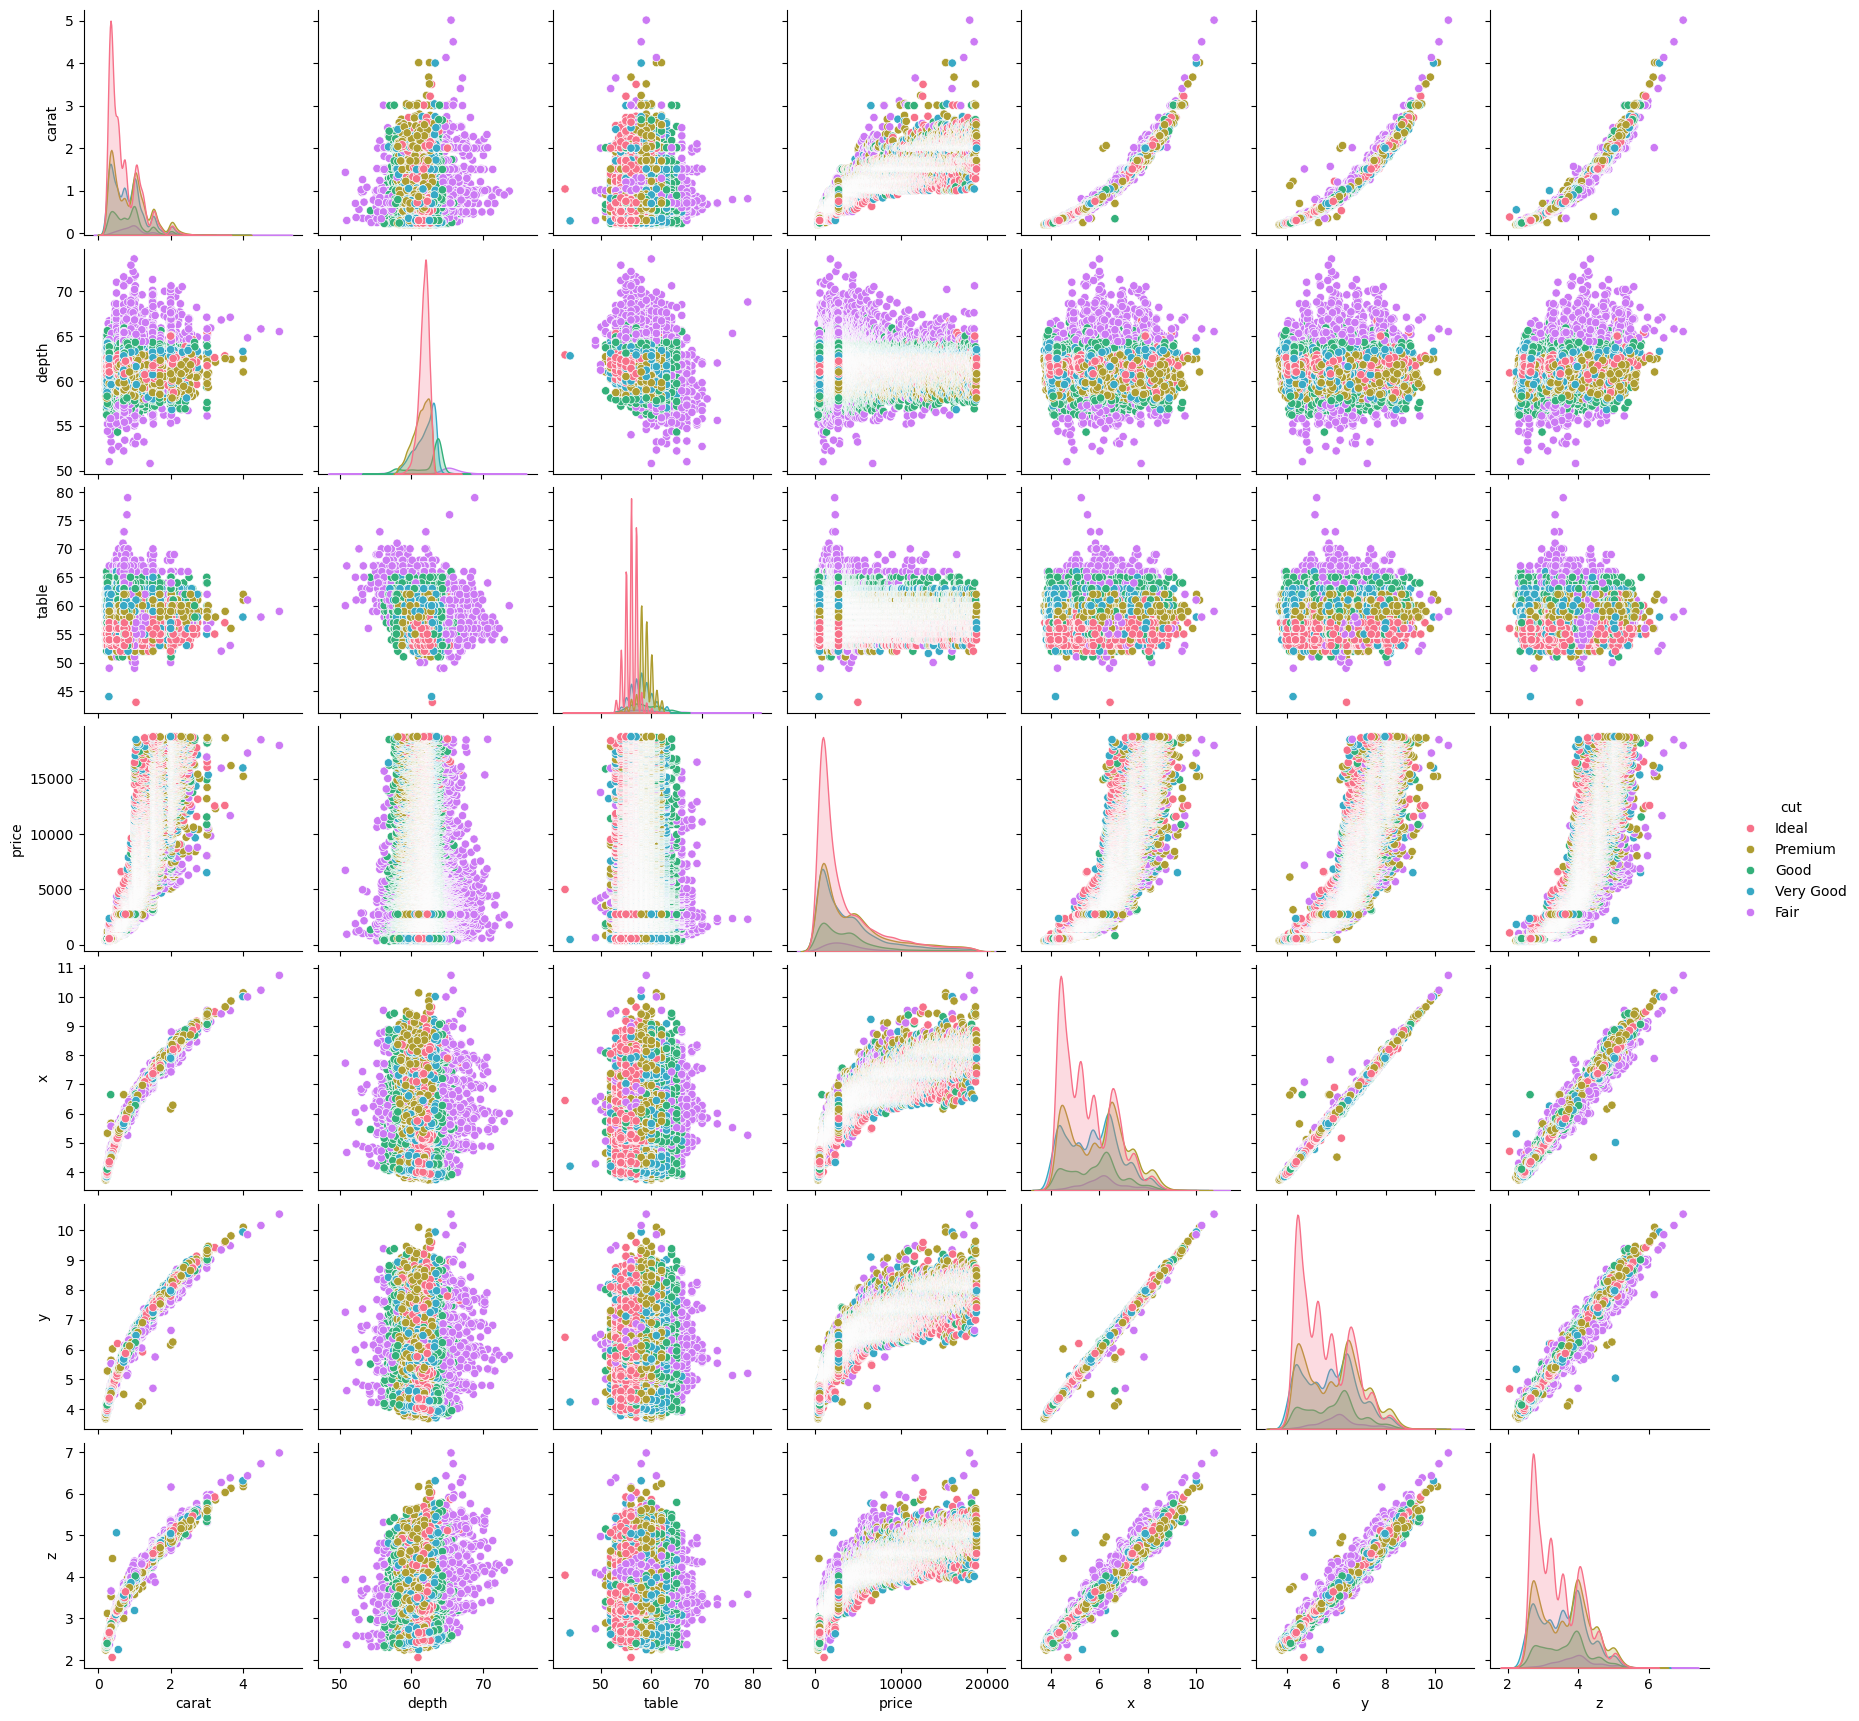

In [15]:
ax=sns.pairplot(df, hue= "cut",palette="husl", diag_kind='kde')
plt.show()

In [16]:
s=(df.dtypes=="object")
object_cols=list(s[s].index)
print(object_cols)
print("Categorical variables: ",object_cols)

['cut', 'color', 'clarity']
Categorical variables:  ['cut', 'color', 'clarity']


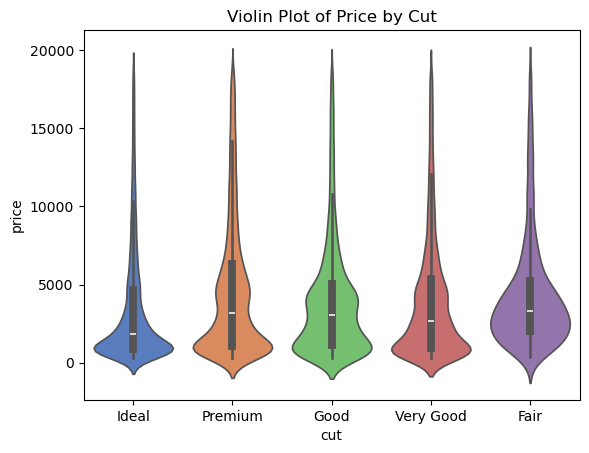

In [17]:
sns.violinplot(x='cut', y='price', data=df, palette="muted")
plt.title("Violin Plot of Price by Cut")
plt.show()

In [18]:
Label_data=df.copy()
label_encoder=LabelEncoder()
for col in object_cols:
    Label_data[col]=label_encoder.fit_transform(Label_data[col])
Label_data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [19]:
df['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [20]:
Label_data['cut'].unique()

array([2, 3, 1, 4, 0])

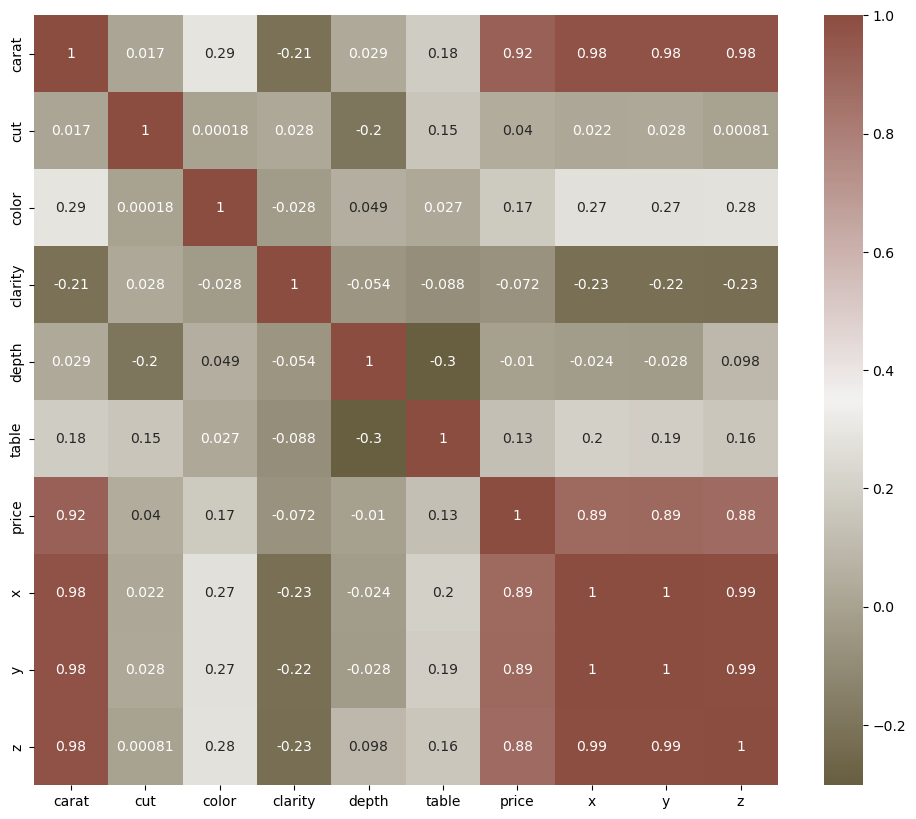

In [21]:
#correlation matrix
cmap=sns.diverging_palette(70,20,s=50,l=40,n=6,as_cmap=True)
corrmat=Label_data.corr()
f,ax=plt.subplots(figsize=(12,10))
sns.heatmap(corrmat,cmap=cmap,annot=True)
plt.show()

## Model Building

In [22]:
Label_data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [23]:
x=Label_data.drop(['price'],axis=1)
y=Label_data['price']
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)
y

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53907, dtype: int64

In [24]:
pipeline_lr=Pipeline([("scalar1",StandardScaler()),
                     ("lr_classifier",LinearRegression())])

pipeline_dt=Pipeline([("scalar2",StandardScaler()),
                     ("dt_classifier",DecisionTreeRegressor())])

pipeline_rf=Pipeline([("scalar3",StandardScaler()),
                     ("rf_classifier",RandomForestRegressor())])


pipeline_kn=Pipeline([("scalar4",StandardScaler()),
                     ("rf_classifier",KNeighborsRegressor())])


pipeline_xgb=Pipeline([("scalar5",StandardScaler()),
                     ("rf_classifier",XGBRegressor())])

# List of all the pipelines
pipelines = [pipeline_lr, pipeline_dt, pipeline_rf, pipeline_kn, pipeline_xgb]

# Dictionary of pipelines and model types for ease of reference
pipe_dict = {0: "LinearRegression", 1: "DecisionTree", 2: "RandomForest",3: "KNeighbors", 4: "XGBRegressor"}

# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train, Y_train)




In [25]:
cv_results_rms = []
for i, model in enumerate(pipelines):
    cv_score = cross_val_score(model, X_train,Y_train,scoring="neg_root_mean_squared_error", cv=10)
    cv_results_rms.append(cv_score)
    print("%s: %f " % (pipe_dict[i], cv_score.mean()))

LinearRegression: -1344.867308 
DecisionTree: -747.439103 
RandomForest: -548.435214 
KNeighbors: -812.732481 
XGBRegressor: -549.222244 


In [26]:
pred = pipeline_xgb.predict(X_test)

In [27]:
print("R^2:",metrics.r2_score(Y_test, pred))
print("Adjusted R^2:",1 - (1-metrics.r2_score(Y_test, pred))*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))
print("MAE:",metrics.mean_absolute_error(Y_test, pred))
print("MSE:",metrics.mean_squared_error(Y_test, pred))
print("RMSE:",np.sqrt(metrics.mean_squared_error(Y_test, pred)))

R^2: 0.9803541302680969
Adjusted R^2: 0.9803377161548786
MAE: 271.9742232464037
MSE: 298375.6294800233
RMSE: 546.2377041911545
